### Imports

In [1]:
import re
import os
import copy
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
)

### Parameters

In [ ]:

DATA_PATH = "cellula toxic data (1).csv"
TEXT_COLS = ["query", "image descriptions"]
LABEL_COL = "Toxic Category"
MIN_FREQ = 2
MAX_LEN_PERCENTILE = 95
EMBED_DIM = 100
HIDDEN_DIM = 128
DROPOUT = 0.3
BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-3
SEED = 42


random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


### Preprocessing

In [ ]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)



def tokenize(text: str):
    text = str(text).lower()
    return word_tokenize(text)


def build_vocab(token_lists, min_freq=2):
    counter = Counter()
    for tokens in token_lists:
        counter.update(tokens)
    vocab = {"<pad>": 0, "<unk>": 1}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab


def encode_and_pad(tokens, vocab, max_len):
    ids = [vocab.get(t, vocab["<unk>"]) for t in tokens][:max_len]
    length = max(len(ids), 1)
    ids = ids + [vocab["<pad>"]] * (max_len - len(ids))
    return ids, length


class TextDataset(Dataset):
    def __init__(self, sequences, lengths, labels):
        self.sequences = torch.as_tensor(sequences, dtype=torch.long)
        self.lengths = torch.as_tensor(lengths, dtype=torch.long)
        self.labels = torch.as_tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.lengths[idx], self.labels[idx]

### RNN Model

In [4]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, pad_idx, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            nonlinearity="tanh",
            batch_first=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, lengths):
        embedded = self.embedding(x)  # (B, T, E)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, hidden = self.rnn(packed)   # hidden: (num_layers, B, H)
        last_hidden = hidden[-1]       # (B, H)
        out = self.dropout(last_hidden)
        return self.fc(out)

### Training

In [5]:
def run_epoch(model, loader, criterion, device, optimizer=None, grad_clip=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds, all_labels = [], []

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for x, lengths, y in loader:
            x, y = x.to(device), y.to(device)

            if is_train:
                optimizer.zero_grad()

            logits = model(x, lengths)
            loss = criterion(logits, y)

            if is_train:
                loss.backward()
                if grad_clip:
                    nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()

            total_loss += loss.item() * x.size(0)
            all_preds.extend(logits.argmax(dim=1).detach().cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    f1_weighted = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, f1_macro, f1_weighted, all_preds, all_labels

### Graphs

In [ ]:
def plot_class_distribution(df, label_col):
    plt.figure(figsize=(9, 5))
    order = df[label_col].value_counts().index
    sns.countplot(y=df[label_col], order=order, hue=df[label_col], legend=False, palette="viridis")
    plt.title("Class Distribution")
    plt.xlabel("Count")
    plt.ylabel("Toxic Category")
    plt.tight_layout()
    plt.show()


def plot_training_curves(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(epochs, history["train_loss"], label="train")
    axes[0].plot(epochs, history["val_loss"], label="val")
    axes[0].set_title("Loss per Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs, history["train_f1"], label="train (macro-F1)")
    axes[1].plot(epochs, history["val_f1"], label="val (macro-F1)")
    axes[1].set_title("Macro-F1 per Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Macro-F1")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names,
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix (Test Set)")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
def export_full_pdf_report(df, history, y_true, y_pred, class_names, output_filename="toxic_model_report.pdf"):
    print(f"Generating PDF report: {output_filename}...")

    with PdfPages(output_filename) as pdf:
        fig, ax = plt.subplots(figsize=(9, 5))
        order = df[LABEL_COL].value_counts().index
        sns.countplot(y=df[LABEL_COL], order=order, hue=df[LABEL_COL], legend=False, palette="viridis", ax=ax)
        ax.set_title("Class Distribution")
        ax.set_xlabel("Count")
        ax.set_ylabel("Toxic Category")
        pdf.savefig(fig, bbox_inches="tight")
        plt.close()

        epochs = range(1, len(history["train_loss"]) + 1)
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        axes[0].plot(epochs, history["train_loss"], label="train")
        axes[0].plot(epochs, history["val_loss"], label="val")
        axes[0].set_title("Loss per Epoch")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].legend()

        axes[1].plot(epochs, history["train_f1"], label="train (macro-F1)")
        axes[1].plot(epochs, history["val_f1"], label="val (macro-F1)")
        axes[1].set_title("Macro-F1 per Epoch")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Macro-F1")
        axes[1].legend()
        pdf.savefig(fig, bbox_inches="tight")
        plt.close()

        cm = confusion_matrix(y_true, y_pred)
        fig, ax = plt.subplots(figsize=(9, 7))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title("Confusion Matrix (Test Set)")
        plt.xticks(rotation=45, ha="right")
        pdf.savefig(fig, bbox_inches="tight")
        plt.close()

    print(f"PDF successfully saved as '{output_filename}'!")    

### Main

Using device: cuda


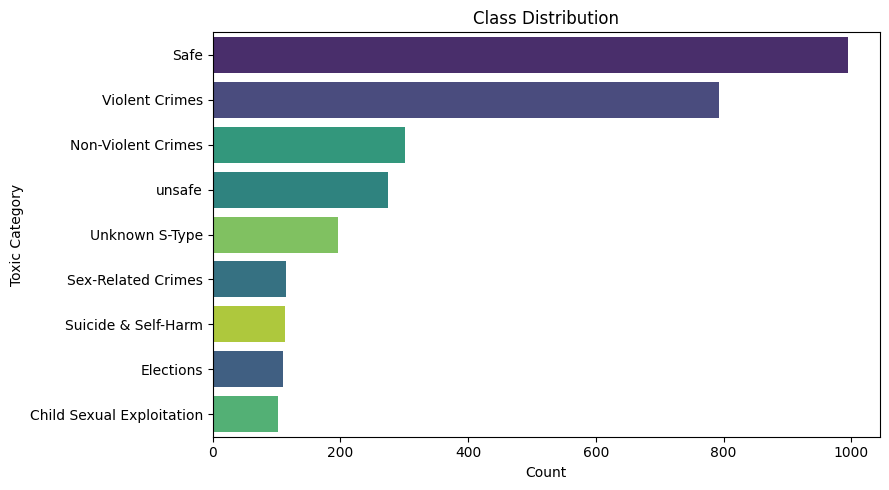

Classes (9): ['Child Sexual Exploitation', 'Elections', 'Non-Violent Crimes', 'Safe', 'Sex-Related Crimes', 'Suicide & Self-Harm', 'Unknown S-Type', 'Violent Crimes', 'unsafe']
Train/Val/Test sizes: 2100/450/450
Vocab size: 1565
Epoch 1 | Train Loss: 1.589 | Val Loss: 1.270 | Val F1: 0.370
Epoch 2 | Train Loss: 1.282 | Val Loss: 1.259 | Val F1: 0.349
Epoch 3 | Train Loss: 1.247 | Val Loss: 1.220 | Val F1: 0.352
Epoch 4 | Train Loss: 1.122 | Val Loss: 0.889 | Val F1: 0.418
Epoch 5 | Train Loss: 0.874 | Val Loss: 0.823 | Val F1: 0.467
Epoch 6 | Train Loss: 0.844 | Val Loss: 0.844 | Val F1: 0.464
Epoch 7 | Train Loss: 0.799 | Val Loss: 0.750 | Val F1: 0.610
Epoch 8 | Train Loss: 0.646 | Val Loss: 0.512 | Val F1: 0.738
Epoch 9 | Train Loss: 0.471 | Val Loss: 0.409 | Val F1: 0.717
Epoch 10 | Train Loss: 0.378 | Val Loss: 0.298 | Val F1: 0.897
Epoch 11 | Train Loss: 0.349 | Val Loss: 0.289 | Val F1: 0.851
Epoch 12 | Train Loss: 0.235 | Val Loss: 0.202 | Val F1: 0.922
Epoch 13 | Train Loss: 0

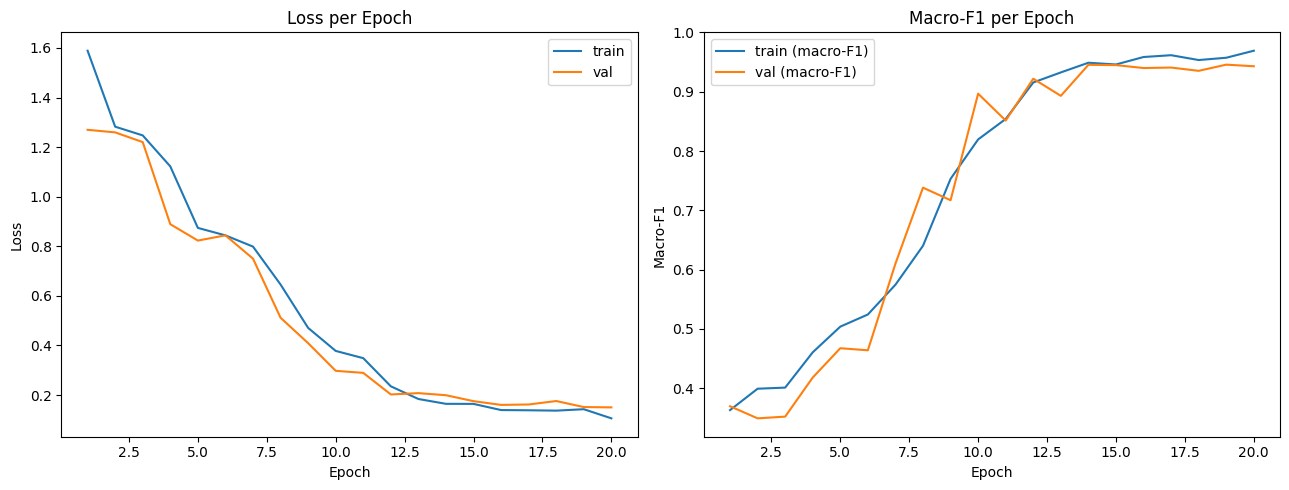


===== TEST SET RESULTS =====
Accuracy:      0.9289
Macro F1:      0.9304
Weighted F1:   0.9258

Per-class report:
                           precision    recall  f1-score   support

Child Sexual Exploitation       1.00      1.00      1.00        15
                Elections       1.00      1.00      1.00        17
       Non-Violent Crimes       0.96      0.98      0.97        45
                     Safe       0.87      0.94      0.90       150
       Sex-Related Crimes       1.00      0.94      0.97        17
      Suicide & Self-Harm       1.00      1.00      1.00        17
           Unknown S-Type       0.70      0.48      0.57        29
           Violent Crimes       0.97      0.95      0.96       119
                   unsafe       1.00      1.00      1.00        41

                 accuracy                           0.93       450
                macro avg       0.94      0.92      0.93       450
             weighted avg       0.93      0.93      0.93       450



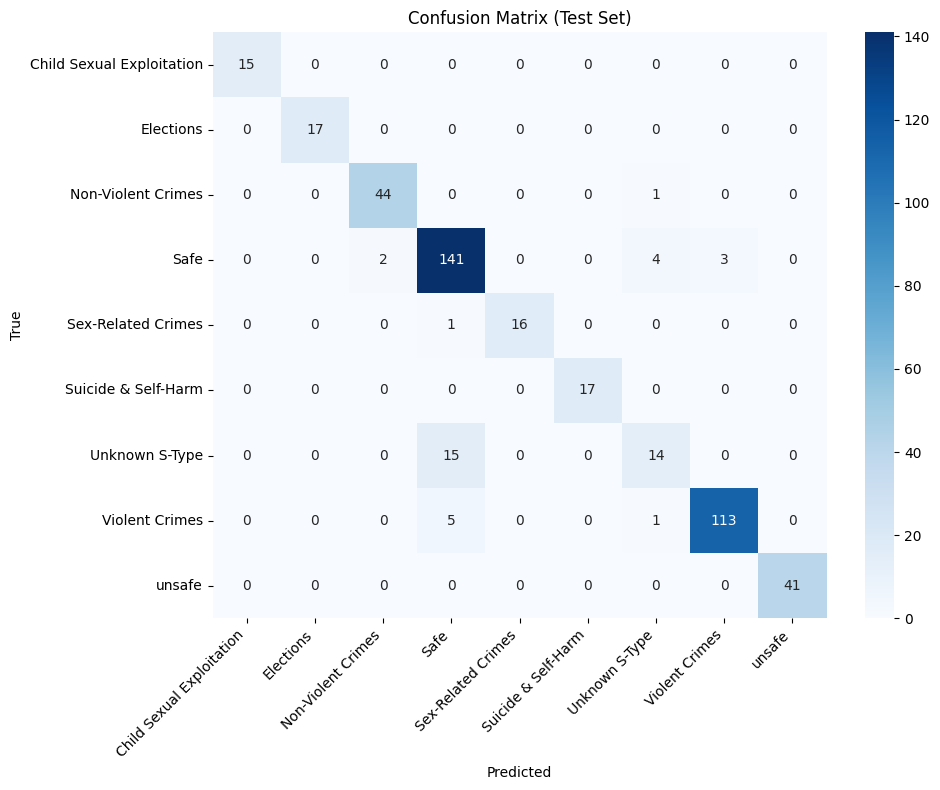

Generating PDF report: toxic_model_report.pdf...
PDF successfully saved as 'toxic_model_report.pdf'!


In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


df = pd.read_csv('cellula toxic data  (1).csv')
df = df.dropna(subset=TEXT_COLS + [LABEL_COL]).reset_index(drop=True)

plot_class_distribution(df, LABEL_COL)

# Combine text fields into one input string per row
df["text"] = df[TEXT_COLS[0]].astype(str)
for col in TEXT_COLS[1:]:
    df["text"] = df["text"] + " [SEP] " + df[col].astype(str)
df["tokens"] = df["text"].apply(tokenize)


label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df[LABEL_COL])
num_classes = len(label_encoder.classes_)
print(f"Classes ({num_classes}): {list(label_encoder.classes_)}")


idx = np.arange(len(df))
idx_train, idx_temp, y_train, y_temp = train_test_split(idx, y, test_size=0.3, random_state=SEED, stratify=y)
idx_val, idx_test, y_val, y_test = train_test_split(idx_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)
print(f"Train/Val/Test sizes: {len(idx_train)}/{len(idx_val)}/{len(idx_test)}")

tokens_train = df["tokens"].iloc[idx_train].tolist()
tokens_val = df["tokens"].iloc[idx_val].tolist()
tokens_test = df["tokens"].iloc[idx_test].tolist()


vocab = build_vocab(tokens_train, min_freq=MIN_FREQ)
print(f"Vocab size: {len(vocab)}")

train_lens = [len(t) for t in tokens_train]
max_len = int(np.percentile(train_lens, MAX_LEN_PERCENTILE))
max_len = max(max_len, 5)


def encode_set(token_lists):
    seqs, lens = [], []
    for tokens in token_lists:
        ids, length = encode_and_pad(tokens, vocab, max_len)
        seqs.append(ids)
        lens.append(length)
    return np.array(seqs), np.array(lens)

X_train, len_train = encode_set(tokens_train)
X_val, len_val = encode_set(tokens_val)
X_test, len_test = encode_set(tokens_test)

train_ds = TextDataset(X_train, len_train, y_train)
val_ds = TextDataset(X_val, len_val, y_val)
test_ds = TextDataset(X_test, len_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


class_weights = compute_class_weight(
    "balanced", classes=np.arange(num_classes), y=y_train
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

model = RNNClassifier(
        vocab_size=len(vocab),
        embed_dim=EMBED_DIM,
        hidden_dim=HIDDEN_DIM,
        num_classes=num_classes,
        pad_idx=vocab["<pad>"],
        dropout=DROPOUT,
    ).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(
    model.parameters(), lr=LR
)

# Training loop
history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
best_val_f1 = -1.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, train_f1, _, _, _ = run_epoch(
        model, train_loader, criterion, device, optimizer=optimizer, grad_clip=5.0
    )
    val_loss, val_acc, val_f1, _, _, _ = run_epoch(
        model, val_loader, criterion, device
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    print(f"Epoch {epoch} | Train Loss: {train_loss:.3f} | Val Loss: {val_loss:.3f} | Val F1: {val_f1:.3f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = copy.deepcopy(model.state_dict())

model.load_state_dict(best_state)
print(f"\nBest validation macro-F1: {best_val_f1:.4f}")

plot_training_curves(history)

#test evaluation
test_loss, test_acc, test_f1_macro, test_f1_weighted, test_preds, test_labels = run_epoch(
    model, test_loader, criterion, device
)

print("\n===== TEST SET RESULTS =====")
print(f"Accuracy:      {test_acc:.4f}")
print(f"Macro F1:      {test_f1_macro:.4f}")
print(f"Weighted F1:   {test_f1_weighted:.4f}")
print("\nPer-class report:")
print(
    classification_report(
        test_labels, test_preds,
        target_names=label_encoder.classes_,
    )
)

plot_confusion_matrix(test_labels, test_preds, label_encoder.classes_)

export_full_pdf_report(
    df=df,
    history=history,
    y_true=test_labels,
    y_pred=test_preds,
    class_names=label_encoder.classes_,
    output_filename="toxic_model_report.pdf"
)